In [2]:
# All the imports

import numpy as np
import math
from skfem import MeshQuad, MeshTri, Basis, asm, condense
from skfem.element import ElementQuad1, ElementTriP1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
from scipy.optimize import curve_fit, brentq, minimize_scalar
import os

In [33]:
# Diffusion coefficient for a M x M checkerboard pattern.
def D_fun(x, M=4, D_max=1.0, D_min=1.0):
    x0 = x[0]; y0 = x[1]
    x_val = (x0 // (1/M)) % 2
    y_val = (y0 // (1/M)) % 2
    same = (x_val == y_val)
    return np.where(same, D_max, D_min)

In [34]:
@BilinearForm
def a(u, v, w):
    return (D_fun(w.x, w.M, w.D_max, w.D_min) * dot(grad(u), grad(v))) + (u * v)

In [4]:
@BilinearForm
def mass(u, v, w):
    return u * v

In [5]:
def fix_sign(u):
    j = np.argmax(np.abs(u))   # index of largest-magnitude component
    return u if u[j] >= 0 else -u

In [6]:
# ChatGPT function for plotting results
def plot_bilinear_hat_solution(U, x, y):
    """
    Plot a 2D bilinear FEM solution from nodal amplitudes.

    Parameters
    ----------
    U : (Nx, Ny) ndarray
        Nodal amplitudes, where U[i, j] corresponds to node (x[i], y[j]).
    x : (Nx,) ndarray
        Grid points in the x-direction.
    y : (Ny,) ndarray
        Grid points in the y-direction.
    plot_type : str
        Either "surface", "contour", or "heatmap".
    """

    U = np.asarray(U)
    x = np.asarray(x)
    y = np.asarray(y)

    if U.shape != (len(x), len(y)):
        raise ValueError(
            f"Expected U.shape == ({len(x)}, {len(y)}), but got {U.shape}."
        )

    X, Y = np.meshgrid(x, y, indexing="ij")

    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, U, levels=50)
    plt.colorbar(label="u(x, y)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Bilinear FEM solution")
    plt.gca().set_aspect("equal")

    plt.tight_layout()
    plt.show()

# ChatGPT function for possibly a better nonuniform grid

In [291]:
def graded_points_on_cell(a, b, n, gamma=2.0, hmin=1e-12):
    t = np.linspace(0.0, 1.0, n + 1)

    if gamma == 1.0:
        s = t
    else:
        s = np.empty_like(t)
        left = t <= 0.5
        s[left] = 0.5 * (2.0 * t[left])**gamma
        s[~left] = 1.0 - 0.5 * (2.0 * (1.0 - t[~left]))**gamma

    x = a + (b - a) * s

    # enforce strictly increasing coordinates
    for i in range(1, len(x)):
        if x[i] <= x[i-1] + hmin:
            x[i] = x[i-1] + hmin

    # rescale back exactly to [a,b]
    x = a + (x - x[0]) * ((b - a) / (x[-1] - x[0]))

    if np.min(np.diff(x)) < hmin / 10:
        raise ValueError("Mesh spacing too small after rescaling.")

    return x


def make_graded_axis(mat_r, n_per_material_cell, gamma=2.0):
    """
    Builds a 1D mesh that exactly includes the material interfaces.

    material_edges = [0, 1/4, 1/2, 3/4, 1]
    n_per_material_cell = number of finite elements inside each material cell
    """
    material_edges = np.linspace(0,1,int(2**mat_r + 1))
    pts = []

    for a, b in zip(material_edges[:-1], material_edges[1:]):
        cell_pts = graded_points_on_cell(a, b, n_per_material_cell, gamma=gamma)

        if len(pts) == 0:
            pts.extend(cell_pts)
        else:
            pts.extend(cell_pts[1:])  # avoid duplicating interface node

    return np.array(pts)


# Plots of the uniform and nonuniform meshes

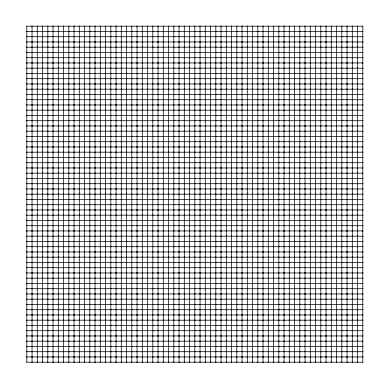

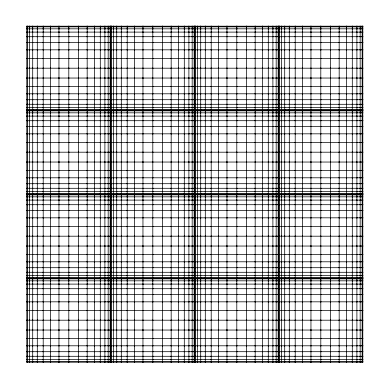

In [302]:
mat_r = 2
min_r = 6

xs = np.linspace(0, 1, int(2**(min_r) + 1))
ys = np.linspace(0, 1, int(2**(min_r) + 1))

# uniform mesh
m = MeshQuad().init_tensor(xs, ys)
ax = m.draw()          # draws the FEM mesh
ax.set_aspect('equal')
plt.show()


# 4x4 2D grid with the power law nonuniform mesh
xs = make_graded_axis(mat_r, n_per_material_cell=int(2**(min_r-mat_r)), gamma=2)
ys = make_graded_axis(mat_r, n_per_material_cell=int(2**(min_r-mat_r)), gamma=2)

# nonuniform mesh
m = MeshQuad().init_tensor(xs, ys)
ax = m.draw()          # draws the FEM mesh
ax.set_aspect('equal')
plt.show()


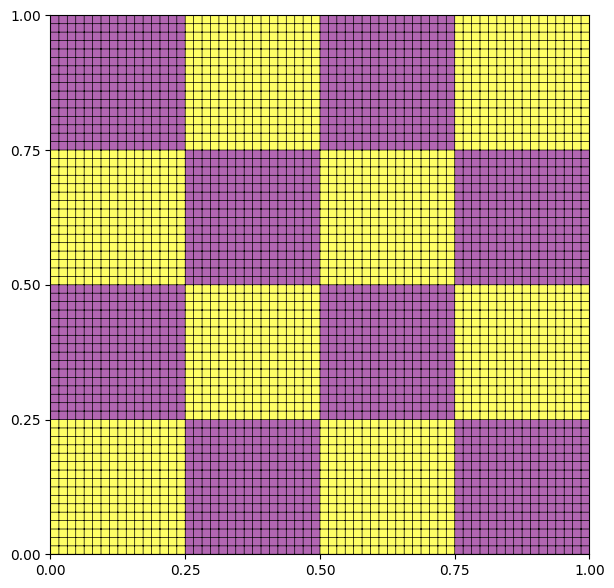

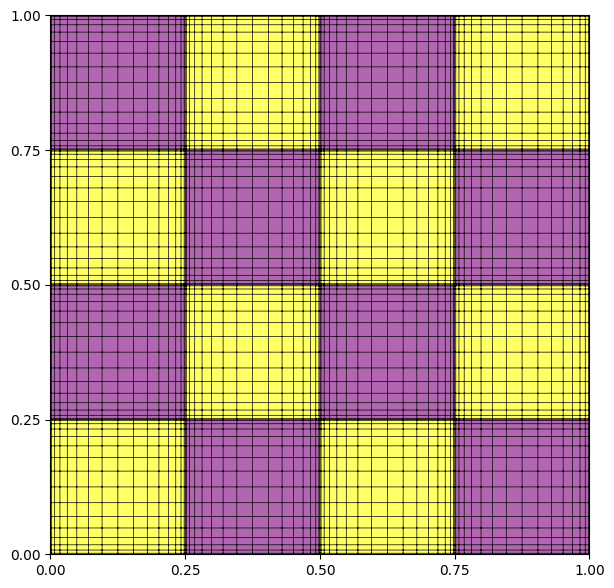

In [314]:
def add_checkerboard_background(
    ax,
    n_cells=4,
    colors=("lightgray", "white"),
    alpha=0.9
):
    """Add a checkerboard background over the unit square."""

    cell_width = 1.0 / n_cells

    for i in range(n_cells):
        for j in range(n_cells):
            rectangle = Rectangle(
                (i * cell_width, j * cell_width),
                cell_width,
                cell_width,
                facecolor=colors[(i + j) % 2],
                edgecolor="none",
                alpha=alpha,
                zorder=-1
            )
            ax.add_patch(rectangle)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


mat_r = 2
min_r = 6

xs = np.linspace(0, 1, int(2**min_r + 1))
ys = np.linspace(0, 1, int(2**min_r + 1))

# Uniform mesh
m = MeshQuad().init_tensor(xs, ys)

fig, ax = plt.subplots(figsize=(7, 7))
add_checkerboard_background(
    ax,
    n_cells=4,
    colors=("yellow", "purple"),
    alpha=0.6
)

m.draw(ax=ax)

ax.set_aspect("equal")
#ax.set_title("Uniform FEM Mesh")
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.show()


# 4x4 material grid with the power-law nonuniform mesh
xs = make_graded_axis(
    mat_r,
    n_per_material_cell=int(2**(min_r - mat_r)),
    gamma=2
)

ys = make_graded_axis(
    mat_r,
    n_per_material_cell=int(2**(min_r - mat_r)),
    gamma=2
)

# Nonuniform mesh
m = MeshQuad().init_tensor(xs, ys)

fig, ax = plt.subplots(figsize=(7, 7))
add_checkerboard_background(
    ax,
    n_cells=4,
    colors=("yellow", "purple"),
    alpha=0.6
)

m.draw(ax=ax)

ax.set_aspect("equal")
#ax.set_title("Power-Law Nonuniform FEM Mesh")
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.show()

In [23]:
# mat_r is the refinement/level of the material discretization
# r is the refinement/level of the finest part of the grid
def eigs_at_level(mat_r, min_r, max_r, D_max=1.0, D_min=1.0, gamma=3.0, do_plot=False, grid="uniform"):
    if grid == "uniform":
        xs = np.linspace(0, 1, int(2**(min_r) + 1))
        ys = np.linspace(0, 1, int(2**(min_r) + 1))
    elif grid == "nonuniform_power_law":
        xs = make_graded_axis(mat_r, n_per_material_cell=2**(min_r-mat_r), gamma=gamma)
        ys = make_graded_axis(mat_r, n_per_material_cell=2**(min_r-mat_r), gamma=gamma)
    
    #m = MeshQuad().init_tensor(xs, ys) # uniform grid
    m = MeshQuad().init_tensor(xs, ys)
    basis = Basis(m, ElementQuad1(), intorder=2)
    A = asm(a, basis, M=int(2**mat_r), D_max=D_max, D_min=D_min)
    M = asm(mass, basis) 

    Boundary_dofs = basis.get_dofs().all()
    A_c, M_c, x0, I = condense(A, M, D=Boundary_dofs)  

    sigma = 0.0
    vals, vecs = eigsh(A_c, k=1, M=M_c, sigma=sigma, which='LM') 

    lambda1 = vals[0]
    u_free = vecs[:, 0]

    u_full = x0.copy()
    u_full[I] = u_free 

    if do_plot:
        # draw the square discretization
        m = MeshQuad().init_tensor(xs, ys)
        ax = m.draw()          
        ax.set_aspect('equal')
        plt.show()

        # prepare the solution array
        u_full = fix_sign(u_full)
        flux_solution = u_full.reshape((int(np.sqrt(len(u_full) + 0.1)), int(np.sqrt(len(u_full) + 0.1)))) # make the flux solution a square matrix
        grid_1D = xs
    
        plot_bilinear_hat_solution(flux_solution, grid_1D, grid_1D) # plot the solution

    return lambda1, u_full, u_full.size, u_free.size

In [82]:
# ChatGPT function for estimating p from a curve fit of nonuniform N values
def estimate_p_from_values(N_vals, eigenvals):
    N_vals = np.asarray(N_vals, dtype=float)
    eigenvals = np.asarray(eigenvals, dtype=float)

    def model(N, Q_inf, C, p):
        return Q_inf + C * N**(-p)

    # Initial guesses
    Q_inf_guess = eigenvals[-1]
    C_guess = eigenvals[0] - eigenvals[-1]
    p_guess = 1.0

    popt, pcov = curve_fit(
        model,
        N_vals,
        eigenvals,
        p0=[Q_inf_guess, C_guess, p_guess],
        maxfev=1000000
    )

    Q_inf, C, p = popt
    return float(Q_inf), float(C), float(p)

In [10]:
def estimate_p_with_ground_truth(N_vals, eigenvals, true_eigenval):
    N_vals = np.asarray(N_vals, dtype=float)
    eigenvals = np.asarray(eigenvals, dtype=float)

    eigenval_errors = eigenvals - true_eigenval
    p_vals = [-1 * math.log(eigenval_errors[i] /eigenval_errors[i+1] ) / math.log(N_vals[i] / N_vals[i+1]) for i in range(len(eigenvals)-1)]
    return p_vals

# get p assuming a constant multiplicative factor between the dependent variable in each data point

In [4]:
# eigenvalue_list: list of eigenvalues from simulations
# DOF_list: list of degrees of freedom for each of those simulations
def get_p_vals(eigenvalue_list, scaling_factor):
    # find the exponents, p, on h using the eigenvalues found
    p_list = []
    for i in range(2,len(eigenvalue_list)): # needs 3 eigenvalues to find p, so len(p_list) = len(L_list) - 2
        p_list.append(math.log((eigenvalue_list[i-2] - eigenvalue_list[i-1]) / (eigenvalue_list[i-1] - eigenvalue_list[i])) / math.log(scaling_factor)) # p value if epsilon = (1/DOF)^p
    return p_list

# D=3

In [11]:
D_max_list = [3]

# uniform simulation

In [18]:
refinement = 10
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement+2, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 3, level: 4, lambda1: 37.431694455922965, full_size: 289, free_size: 225
D_max: 3, level: 5, lambda1: 37.09106684924292, full_size: 1089, free_size: 961
D_max: 3, level: 6, lambda1: 36.97261128693088, full_size: 4225, free_size: 3969
D_max: 3, level: 7, lambda1: 36.929645581948854, full_size: 16641, free_size: 16129
D_max: 3, level: 8, lambda1: 36.91359642681871, full_size: 66049, free_size: 65025
D_max: 3, level: 9, lambda1: 36.90747789876387, full_size: 263169, free_size: 261121
DOFs:  [225, 961, 3969, 16129, 65025, 261121]
eigenvalues:  [37.431694455922965, 37.09106684924292, 36.97261128693088, 36.929645581948854, 36.91359642681871, 36.90747789876387]


# get uniform fit

In [13]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [36.90567770901212, 36.90448003177553, 36.90388946536569, 36.90368113248141]
C estimates from curve fit:  [25.737358414880354, 24.52478923126219, 22.69705716903063, 20.878223309375507]
p estimates from curve fit:  [0.7182964699382877, 0.7103321532491286, 0.6999439016071922, 0.6904908454431894]


C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:7: RuntimeWarning: overflow encountered in multiply
  return Q_inf + C * N**(-p)


# nonuniform power law simulation

In [19]:
refinement = 10
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=5, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 3, level: 2, lambda1: 42.01846569374839, full_size: 25, free_size: 9
D_max: 3, level: 3, lambda1: 38.465686305068154, full_size: 81, free_size: 49
D_max: 3, level: 4, lambda1: 38.15922022538205, full_size: 289, free_size: 225
D_max: 3, level: 5, lambda1: 37.38656608051444, full_size: 1089, free_size: 961
D_max: 3, level: 6, lambda1: 37.04124657479189, full_size: 4225, free_size: 3969
D_max: 3, level: 7, lambda1: 36.93929191555345, full_size: 16641, free_size: 16129
D_max: 3, level: 8, lambda1: 36.91260312451455, full_size: 66049, free_size: 65025
D_max: 3, level: 9, lambda1: 36.90583701468156, full_size: 263169, free_size: 261121
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121]
eigenvalues:  [42.01846569374839, 38.465686305068154, 38.15922022538205, 37.38656608051444, 37.04124657479189, 36.93929191555345, 36.91260312451455, 36.90583701468156]


# get nonuniform power law fit

In [ ]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)
    
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [36.74441038093566, 36.895358863043604, 36.903006245812904, 36.90352304949599]
C estimates from curve fit:  [26.94310417441625, 175.55340631989648, 374.6979214040272, 491.1592639647618]
p estimates from curve fit:  [0.5440689858906511, 0.8559776383498131, 0.953973533883895, 0.9833895449429723]


C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# D=3 Results

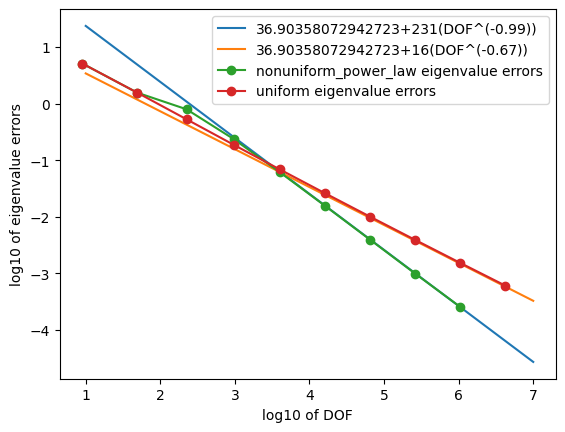

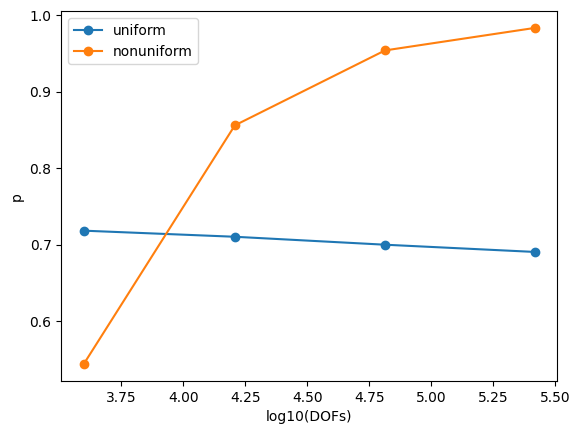

In [27]:
mat_r = 2

# D_max = 3
N_2D_nonuniform_power_law = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues = np.array([42.0184656937484, 38.46568630506813, 37.69728781231426, 37.14020012930127, 36.965364164063665, 36.919204496306904, 36.90750524187968, 36.904570379548225, 36.903836061503995])

# uniform data set, D_max=3
N_2D_uniform = [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209]
uniform_eigenvalues = np.array([42.0184656937484, 38.46568630506816, 37.431694455922965, 37.09106684924295, 36.97261128693089, 36.929645581948854, 36.91359642681871, 36.90747789876389, 36.90511260452845, 36.90418969992967])


############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 36.90358072942723 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(1,8))

p_fit_power_law = 0.99
C_nonuniform_power_law = 231
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error))

C_uniform = 16
p_fit = 0.67
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error))

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues - true_eigenvalue), '-o')

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o')
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend([str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))", str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))", "nonuniform_power_law eigenvalue errors","uniform eigenvalue errors"])
plt.show()


######### p value plots ######### 
p_DOFs = [3969, 16129, 65025, 261121]

# uniform
p_uniform = [0.7182964699382877, 0.7103321532491286, 0.6999439016071922, 0.6904908454431894]
p_nonuniform = [0.5440689858906511, 0.8559776383498131, 0.953973533883895, 0.9833895449429723]
plt.plot(np.log10(p_DOFs), p_uniform, '-o', label='uniform')
plt.plot(np.log10(p_DOFs), p_nonuniform, '-o', label='nonuniform')
plt.xlabel("log10(DOFs)")
plt.ylabel("p")
plt.legend()
plt.show()


# D=10

In [85]:
D_max_list = [10]

# uniform simulation

In [103]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement+2, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 10, level: 4, lambda1: 80.87534653712605, full_size: 289, free_size: 225
D_max: 10, level: 5, lambda1: 77.2411099603206, full_size: 1089, free_size: 961
D_max: 10, level: 6, lambda1: 75.31771940270087, full_size: 4225, free_size: 3969
D_max: 10, level: 7, lambda1: 74.23761428240434, full_size: 16641, free_size: 16129
D_max: 10, level: 8, lambda1: 73.61728908017767, full_size: 66049, free_size: 65025
D_max: 10, level: 9, lambda1: 73.25799045612766, full_size: 263169, free_size: 261121
D_max: 10, level: 10, lambda1: 73.04919713544778, full_size: 1050625, free_size: 1046529
DOFs:  [225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [80.87534653712605, 77.2411099603206, 75.31771940270087, 74.23761428240434, 73.61728908017767, 73.25799045612766, 73.04919713544778]


# get uniform fit

In [104]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [73.00398189940093, 72.80545548600082, 72.76562903711341, 72.75908015562109, 72.75827301616911]
C estimates from curve fit:  [79.33278376610821, 69.58467642640015, 65.96497164649425, 64.79182387208206, 64.50398200128625]
p estimates from curve fit:  [0.4265836748335662, 0.4008269451374716, 0.3924819380388653, 0.39017158204682295, 0.38968500410627543]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# nonuniform power law simulation

In [86]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=3, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 10, level: 2, lambda1: 111.2930724642858, full_size: 25, free_size: 9
D_max: 10, level: 3, lambda1: 88.72364240425755, full_size: 81, free_size: 49
D_max: 10, level: 4, lambda1: 79.38537201991326, full_size: 289, free_size: 225
D_max: 10, level: 5, lambda1: 74.80955063381788, full_size: 1089, free_size: 961
D_max: 10, level: 6, lambda1: 73.3339000225226, full_size: 4225, free_size: 3969
D_max: 10, level: 7, lambda1: 72.91390220571112, full_size: 16641, free_size: 16129
D_max: 10, level: 8, lambda1: 72.7995067348077, full_size: 66049, free_size: 65025
D_max: 10, level: 9, lambda1: 72.76908897709403, full_size: 263169, free_size: 261121
D_max: 10, level: 10, lambda1: 72.76112721851152, full_size: 1050625, free_size: 1046529
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [111.2930724642858, 88.72364240425755, 79.38537201991326, 74.80955063381788, 73.3339000225226, 72.91390220571112, 72.7995067348077, 72.76908897709403, 72.76112721851152]


# get nonuniform power law fit

In [29]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit of 3 points at a time
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [36.88066269976101, 36.902172388096986, 36.903477382259766, 36.90358072942713, 36.90383606150436]
C estimates from curve fit:  [58.763925886411464, 146.4533727171216, 203.08309902282537, 230.86630709752532, 0.003669180375410974]
p estimates from curve fit:  [0.7895169941003112, 0.9350755801975527, 0.9770456970330861, 0.9909609827861526, 1.0]


C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_45480\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# D=10 Results

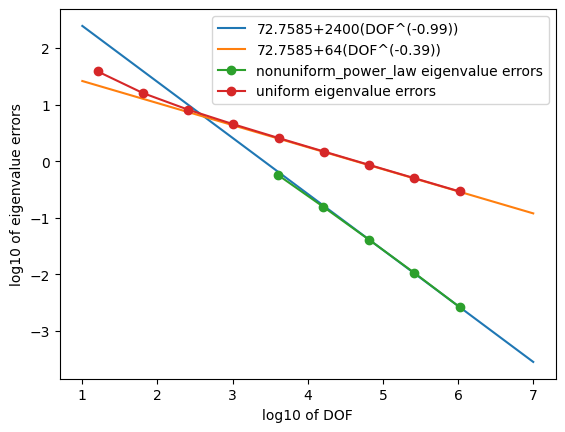

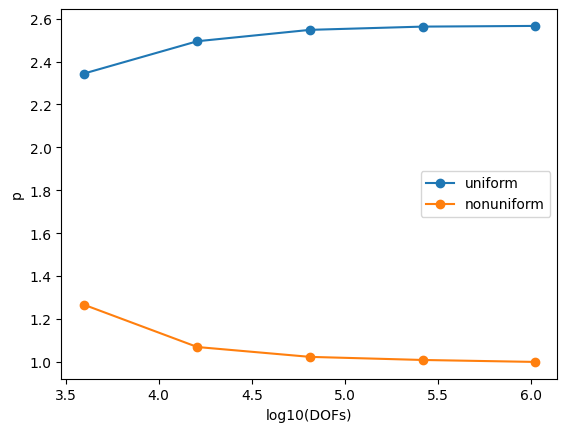

In [31]:
mat_r = 2

# D_max = 10
N_2D_nonuniform_power_law = np.array([3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues = np.array([73.3339000225226, 72.91390220571122, 72.79950673480761, 72.76908897709329, 72.76112721851132])

# uniform data set, D_max=10
uniform_r = np.arange(2,11)
uniform_eigenvalues = np.array([111.2930724642858, 88.72364240425755, 80.87534653712605, 77.24110996032059, 75.31771940270085, 74.23761428240432, 73.61728908017768, 73.25799045612763, 73.0491971354478])

N_1D_uniform = 2**(uniform_r)
N_2D_uniform = N_1D_uniform**2

############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 72.7585 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(1,8))

p_fit_power_law = 0.99
C_nonuniform_power_law = 2400
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error))

C_uniform = 64
p_fit = 0.39
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error))

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues - true_eigenvalue), '-o')

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o')
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend([str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))", str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))", "nonuniform_power_law eigenvalue errors","uniform eigenvalue errors"])
plt.show()


######### p value plots ######### 
p_DOFs = [3969, 16129, 65025, 261121, 1046529]

# uniform
p_uniform = np.array([0.4265836748335662, 0.4008269451374716, 0.3924819380388653, 0.39017158204682295, 0.38968500410627543])
p_nonuniform = np.array([0.7895169941003112, 0.9350755801975527, 0.9770456970330861, 0.9909609827861526, 1.0])
plt.plot(np.log10(p_DOFs), 1/p_uniform, '-o', label='uniform')
plt.plot(np.log10(p_DOFs), 1/p_nonuniform, '-o', label='nonuniform')
plt.xlabel("log10(DOFs)")
plt.ylabel("p")
plt.legend()
plt.show()


# D=50

In [140]:
D_max_list = [50]

# uniform simulation

In [118]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement+2, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 50, level: 4, lambda1: 225.4127666014158, full_size: 289, free_size: 225
D_max: 50, level: 5, lambda1: 208.6556188850094, full_size: 1089, free_size: 961
D_max: 50, level: 6, lambda1: 197.94476436837732, full_size: 4225, free_size: 3969
D_max: 50, level: 7, lambda1: 189.82035759063174, full_size: 16641, free_size: 16129
D_max: 50, level: 8, lambda1: 183.40271706897943, full_size: 66049, free_size: 65025
D_max: 50, level: 9, lambda1: 178.31425602446134, full_size: 263169, free_size: 261121
D_max: 50, level: 10, lambda1: 174.29375281675246, full_size: 1050625, free_size: 1046529
DOFs:  [225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [225.4127666014158, 208.6556188850094, 197.94476436837732, 189.82035759063174, 183.40271706897943, 178.31425602446134, 174.29375281675246]


# get uniform fit

In [119]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [177.35597452451867, 162.85036013783693, 158.51990417130142, 158.5321806672419, 159.0429049517018]
C estimates from curve fit:  [237.91203193560094, 166.36951067023404, 154.18974548982877, 154.23770524196684, 157.72514530568282]
p estimates from curve fit:  [0.2953264144061817, 0.18780098778944637, 0.16458399989655303, 0.1646565907065563, 0.16854632397800923]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in multiply
  return Q_inf + C * N**(-p)


# nonuniform power law simulation

In [157]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=6, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 50, level: 2, lambda1: 505.1223162797624, full_size: 25, free_size: 9
D_max: 50, level: 3, lambda1: 266.41425218381056, full_size: 81, free_size: 49
D_max: 50, level: 4, lambda1: 236.78834423395944, full_size: 289, free_size: 225
D_max: 50, level: 5, lambda1: 191.76220737706907, full_size: 1089, free_size: 961
D_max: 50, level: 6, lambda1: 169.70276585617088, full_size: 4225, free_size: 3969
D_max: 50, level: 7, lambda1: 162.6022693521492, full_size: 16641, free_size: 16129
D_max: 50, level: 8, lambda1: 160.5363221856587, full_size: 66049, free_size: 65025
D_max: 50, level: 9, lambda1: 159.95585700722054, full_size: 263169, free_size: 261121
D_max: 50, level: 10, lambda1: 159.84527162415154, full_size: 1050625, free_size: 1046529
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [505.1223162797624, 266.41425218381056, 236.78834423395944, 191.76220737706907, 169.70276585617088, 162.6022693521492, 160.5363221856587, 159.95585700722054, 159.84527162415154]

# get nonuniform power law fit

In [149]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit of 3 points at a time
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)

lambda_inf estimates from curve fit:  [152.16366305087965, 159.3309091289626, 159.68444113188488, 159.72668225736757, 159.73487454639755, 159.78436567301634]
C estimates from curve fit:  [1300.5459314626844, 5029.530526097304, 7468.723032395303, 9052.445103058015, 10444.002215022821, 0.2419056350625226]
p estimates from curve fit:  [0.5239526002120148, 0.7536304840584707, 0.8058001725494366, 0.8270944820128562, 0.8407818433843245, 1.0]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# Plot D=50 Results

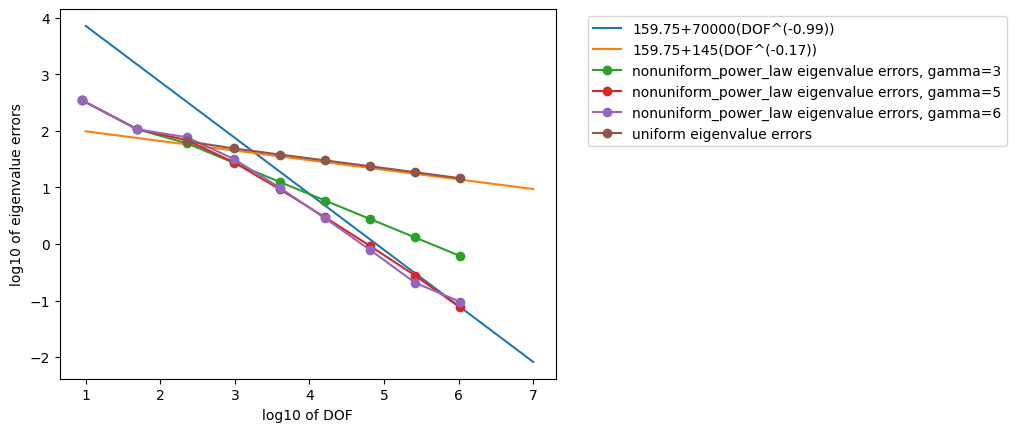

In [175]:
mat_r = 2

# D_max = 50
N_2D_nonuniform_power_law = np.array( [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_gamma_3 = np.array([505.12231627976263, 266.41425218381045, 220.27103823713486, 187.10513004279306, 172.2846513413984, 165.61466934057287, 162.5143341160425, 161.05391325499247, 160.36253709761914])
nonuniform_power_law_eigenvalues_gamma_5 = np.array([505.1223162797623, 266.41425218381085, 228.3178083501097, 187.75301009723898, 169.09095075351004, 162.72361503812664, 160.67268782374953, 160.02627130807886, 159.8255666317168])
nonuniform_power_law_eigenvalues_gamma_6 = np.array([505.1223162797624, 266.41425218381056, 236.78834423395944, 191.76220737706907, 169.70276585617088, 162.6022693521492, 160.5363221856587, 159.95585700722054, 159.84527162415154])

# uniform data set, D_max=50
N_2D_uniform = np.array([225, 961, 3969, 16129, 65025, 261121, 1046529])
uniform_eigenvalues = np.array([225.4127666014158, 208.6556188850094, 197.94476436837732, 189.82035759063174, 183.40271706897943, 178.31425602446134, 174.29375281675246])

############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 159.75 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(1,8))

p_fit_power_law = 0.99
C_nonuniform_power_law = 70000
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error))

C_uniform = 145
p_fit = 0.17
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error))

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_3 - true_eigenvalue), '-o')
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_5 - true_eigenvalue), '-o')
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_6 - true_eigenvalue), '-o')

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o')
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend([str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))", str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))", 
            "nonuniform_power_law eigenvalue errors, gamma=3", "nonuniform_power_law eigenvalue errors, gamma=5","nonuniform_power_law eigenvalue errors, gamma=6","uniform eigenvalue errors"], bbox_to_anchor=(1.05, 1), loc='upper left',)
plt.show()


# D=100

In [176]:
D_max_list = [100]

# uniform simulation

In [177]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement+2, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 100, level: 4, lambda1: 281.90097992015194, full_size: 289, free_size: 225
D_max: 100, level: 5, lambda1: 266.1843516579912, full_size: 1089, free_size: 961
D_max: 100, level: 6, lambda1: 257.6050625821795, full_size: 4225, free_size: 3969
D_max: 100, level: 7, lambda1: 250.91248842453643, full_size: 16641, free_size: 16129
D_max: 100, level: 8, lambda1: 245.0089579755079, full_size: 66049, free_size: 65025
D_max: 100, level: 9, lambda1: 239.69309107547795, full_size: 263169, free_size: 261121
D_max: 100, level: 10, lambda1: 234.93794577705353, full_size: 1050625, free_size: 1046529
DOFs:  [225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [281.90097992015194, 266.1843516579912, 257.6050625821795, 250.91248842453643, 245.0089579755079, 239.69309107547795, 234.93794577705353]


# get uniform fit

In [178]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [246.55303990508332, 225.70398724807418, 198.464154556226, 190.12659452956595, 194.0345554690943]
C estimates from curve fit:  [317.079853206918, 128.27425666681899, 120.26115470020088, 123.63540607934354, 122.6438681257214]
p estimates from curve fit:  [0.4050725365894405, 0.16793213051351125, 0.08565287469392126, 0.07328156350446248, 0.07922030528920866]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# nonuniform simulation

In [192]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=8, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 100, level: 2, lambda1: 997.2048853317641, full_size: 25, free_size: 9
D_max: 100, level: 3, lambda1: 331.0092929082221, full_size: 81, free_size: 49
D_max: 100, level: 4, lambda1: 320.0550721194057, full_size: 289, free_size: 225
D_max: 100, level: 5, lambda1: 272.43457210960815, full_size: 1089, free_size: 961
D_max: 100, level: 6, lambda1: 229.82955717643114, full_size: 4225, free_size: 3969
D_max: 100, level: 7, lambda1: 212.99367644749745, full_size: 16641, free_size: 16129
D_max: 100, level: 8, lambda1: 207.87171738590854, full_size: 66049, free_size: 65025
D_max: 100, level: 9, lambda1: 199.63225528709137, full_size: 263169, free_size: 261121


Exception: Zero Jacobian determinant

# get nonuniform power law fit

In [180]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit of 3 points at a time
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)

lambda_inf estimates from curve fit:  [137.0933247625821, 204.1265035294645, 205.69042663590008, 205.75704501685237, 205.901256163697]
C estimates from curve fit:  [583.1186142120694, 4957.251995551162, 9395.548008935462, 10454.397605534414, 25071.15709251862]
p estimates from curve fit:  [0.22655727472332207, 0.6527938722451465, 0.7387782568237645, 0.7507442414766771, 0.8349306692854492]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in multiply
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# plot D=100 results

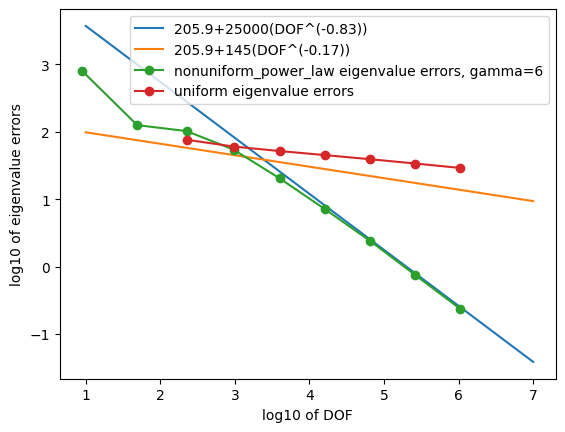

In [191]:
mat_r = 2

# D_max = 50
N_2D_nonuniform_power_law = np.array( [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_gamma_6 = np.array([997.2048853317641, 331.0092929082224, 308.03692412617005, 260.11998177872806, 226.31071654499277, 213.00911449051955, 208.30332788850066, 206.6537224187373, 206.13735803187294])
#nonuniform_power_law_eigenvalues_gamma_8 = np.array([4933.681741288396, 375.915224857852, 370.3433349274005, 345.0451234611742, 312.1049407330937, 295.8248415712042, 288.94478236026, 285.4348046385489, 283.3993497205607])

# uniform data set, D_max=500
N_2D_uniform = np.array([225, 961, 3969, 16129, 65025, 261121, 1046529])
uniform_eigenvalues = np.array([281.90097992015194, 266.1843516579912, 257.6050625821795, 250.91248842453643, 245.0089579755079, 239.69309107547795, 234.93794577705353])

############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 205.9# "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(1,8))

p_fit_power_law = 0.83
C_nonuniform_power_law = 25000
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error))

C_uniform = 145
p_fit = 0.17
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error))

# plot of nonuniform power law eigenvalues vs DOF
#plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_3 - true_eigenvalue), '-o')
#plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_5 - true_eigenvalue), '-o')
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_6 - true_eigenvalue), '-o')

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o')
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend([str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))", str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))", 
            "nonuniform_power_law eigenvalue errors, gamma=6","uniform eigenvalue errors"])
plt.show()


# D=500

In [160]:
D_max_list = [500]

# uniform simulation

In [161]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement+2, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 500, level: 4, lambda1: 324.48931466842953, full_size: 289, free_size: 225
D_max: 500, level: 5, lambda1: 311.57924707759236, full_size: 1089, free_size: 961
D_max: 500, level: 6, lambda1: 307.6639128179995, full_size: 4225, free_size: 3969
D_max: 500, level: 7, lambda1: 305.92388769591304, full_size: 16641, free_size: 16129
D_max: 500, level: 8, lambda1: 304.7187870099171, full_size: 66049, free_size: 65025
D_max: 500, level: 9, lambda1: 303.647506556733, full_size: 263169, free_size: 261121
D_max: 500, level: 10, lambda1: 302.6134835922933, full_size: 1050625, free_size: 1046529
DOFs:  [225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [324.48931466842953, 311.57924707759236, 307.6639128179995, 305.92388769591304, 304.7187870099171, 303.647506556733, 302.6134835922933]


# get uniform fit

In [162]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [305.8588823680216, 304.4893564948107, 301.9428931385557, 294.8340479246321, 303.6599257193258]
C estimates from curve fit:  [1524.6830643390256, 347.08192904598855, 48.772182470943164, 24.666769135168554, 252957.71823301888]
p estimates from curve fit:  [0.8132687957763508, 0.56652671069127, 0.2586221792649132, 0.08251411342768769, 4705.922395716986]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)


# nonuniform power law simulation

In [168]:
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=8, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 500, level: 2, lambda1: 4933.681741288396, full_size: 25, free_size: 9
D_max: 500, level: 3, lambda1: 375.915224857852, full_size: 81, free_size: 49
D_max: 500, level: 4, lambda1: 372.37188834930566, full_size: 289, free_size: 225
D_max: 500, level: 5, lambda1: 354.5275564440197, full_size: 1089, free_size: 961
D_max: 500, level: 6, lambda1: 319.19779202837304, full_size: 4225, free_size: 3969
D_max: 500, level: 7, lambda1: 296.50093313800767, full_size: 16641, free_size: 16129
D_max: 500, level: 8, lambda1: 287.3318575992142, full_size: 66049, free_size: 65025
D_max: 500, level: 9, lambda1: 269.9309789990463, full_size: 263169, free_size: 261121


Exception: Zero Jacobian determinant

# get nonuniform power law fit

In [164]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,refinement-mat_refinement-4):
    # using polynomial fit of 3 points at a time
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)

lambda_inf estimates from curve fit:  [-263440.177933197, 279.4034620007435, 283.8345638233194, 281.749960523009, 280.57729042219]
C estimates from curve fit:  [263921.76380960783, 1916.6973923586393, 4495.474119924893, 1491.5563685812933, 638.8378010989879]
p estimates from curve fit:  [7.68797915666664e-05, 0.4912872554934562, 0.6117363118941868, 0.48131746261251507, 0.3911830184405345]


C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_57460\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# plot D=500 results

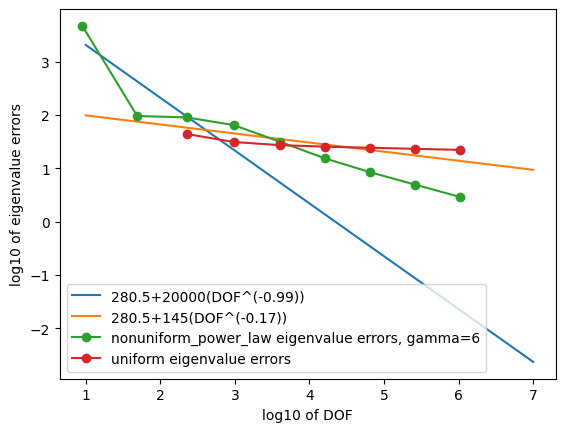

In [169]:
mat_r = 2

# D_max = 50
N_2D_nonuniform_power_law = np.array( [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_gamma_6 = np.array([4933.681741288396, 375.915224857852, 370.3433349274005, 345.0451234611742, 312.1049407330937, 295.8248415712042, 288.94478236026, 285.4348046385489, 283.3993497205607])
#nonuniform_power_law_eigenvalues_gamma_8 = np.array([4933.681741288396, 375.915224857852, 370.3433349274005, 345.0451234611742, 312.1049407330937, 295.8248415712042, 288.94478236026, 285.4348046385489, 283.3993497205607])

# uniform data set, D_max=500
N_2D_uniform = np.array([225, 961, 3969, 16129, 65025, 261121, 1046529])
uniform_eigenvalues = np.array([324.48931466842953, 311.57924707759236, 307.6639128179995, 305.92388769591304, 304.7187870099171, 303.647506556733, 302.6134835922933])

############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 280.5 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(1,8))

p_fit_power_law = 0.99
C_nonuniform_power_law = 20000
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error))

C_uniform = 145
p_fit = 0.17
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error))

# plot of nonuniform power law eigenvalues vs DOF
#plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_3 - true_eigenvalue), '-o')
#plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_5 - true_eigenvalue), '-o')
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues_gamma_6 - true_eigenvalue), '-o')

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o')
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend([str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))", str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))", 
            "nonuniform_power_law eigenvalue errors, gamma=6","uniform eigenvalue errors"])
plt.show()


# COMBINED PLOT OF RESULTS

# get a list of the fit parameters

In [77]:
# sz is the number of data points to use per fit
def get_fit_parameters(N_vals, lambda_vals, mat_r, sz=3):
    # get the p values from curve fitting only 3 points at a time
    lambda_inf_values_fit = []
    C_values_fit = []
    p_values_fit = []
    for q in range(0,len(N_vals)-sz+1):
        # using polynomial fit
        lambda_inf, C, p_fit = estimate_p_from_values(N_vals[-sz-q:-q], lambda_vals[-sz-q:-q]) if q != 0 else estimate_p_from_values(N_vals[-sz:], lambda_vals[-sz:])
        lambda_inf_values_fit.append(lambda_inf)
        C_values_fit.append(C)
        p_values_fit.append(p_fit)

    lambda_inf_values_fit = lambda_inf_values_fit[::-1]
    C_values_fit = C_values_fit[::-1]
    p_values_fit = p_values_fit[::-1]

    return lambda_inf_values_fit, C_values_fit, p_values_fit

# Uniform simulation box (to get the gamma values)

In [321]:
D_max_list = [1,3,10,20,30,40,50]
refinement = 12
mat_refinement = 2
for D_max in D_max_list:
    Data_dict = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict["levels"].append(r)
        Data_dict["lambda1"].append(float(lambda1))
        Data_dict["full_size"].append(full_size)
        Data_dict["free_size"].append(free_size)
        Data_dict["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict["free_size"])
    print("eigenvalues: ", Data_dict["lambda1"])

    lambda_inf_values_fit, C_values_fit, p_values_fit = get_fit_parameters(Data_dict["free_size"], Data_dict["lambda1"], mat_r, sz=3)
    print("P values: ", p_values_fit)

D_max: 1, level: 2, lambda1: 21.773284010442463, full_size: 25, free_size: 9
D_max: 1, level: 3, lambda1: 20.994161312494526, full_size: 81, free_size: 49
D_max: 1, level: 4, lambda1: 20.802707356797875, full_size: 289, free_size: 225
D_max: 1, level: 5, lambda1: 20.755068235068745, full_size: 1089, free_size: 961
D_max: 1, level: 6, lambda1: 20.743172706514034, full_size: 4225, free_size: 3969
D_max: 1, level: 7, lambda1: 20.740199718588208, full_size: 16641, free_size: 16129
D_max: 1, level: 8, lambda1: 20.739456527549468, full_size: 66049, free_size: 65025
D_max: 1, level: 9, lambda1: 20.7392707333196, full_size: 263169, free_size: 261121
D_max: 1, level: 10, lambda1: 20.73922428463772, full_size: 1050625, free_size: 1046529
D_max: 1, level: 11, lambda1: 20.739212673877596, full_size: 4198401, free_size: 4190209
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209]
eigenvalues:  [21.773284010442463, 20.994161312494526, 20.802707356797875, 20.755068235068745, 20.7431

C:\Users\linco\AppData\Local\Temp\ipykernel_45480\1438594737.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
C:\Users\linco\AppData\Local\Temp\ipykernel_45480\1438594737.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)


D_max: 3, level: 7, lambda1: 36.92964558194884, full_size: 16641, free_size: 16129
D_max: 3, level: 8, lambda1: 36.9135964268187, full_size: 66049, free_size: 65025
D_max: 3, level: 9, lambda1: 36.90747789876388, full_size: 263169, free_size: 261121
D_max: 3, level: 10, lambda1: 36.90511260452843, full_size: 1050625, free_size: 1046529
D_max: 3, level: 11, lambda1: 36.90418969992967, full_size: 4198401, free_size: 4190209
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209]
eigenvalues:  [42.01846569374839, 38.465686305068154, 37.43169445592296, 37.091066849242935, 36.97261128693088, 36.92964558194884, 36.9135964268187, 36.90747789876388, 36.90511260452843, 36.90418969992967]
P values:  [0.6943977962834442, 0.7104974771303497, 0.7182964699381937, 0.7103321532491386, 0.6999439016098233, 0.6904908454440635, 0.6830415332189717, 1.0]
D_max: 10, level: 2, lambda1: 111.29307246428579, full_size: 25, free_size: 9
D_max: 10, level: 3, lambda1: 88.72364240425748, full_size: 81

C:\Users\linco\AppData\Local\Temp\ipykernel_45480\1438594737.py:7: RuntimeWarning: overflow encountered in multiply
  return Q_inf + C * N**(-p)


D_max: 10, level: 7, lambda1: 74.23761428240431, full_size: 16641, free_size: 16129
D_max: 10, level: 8, lambda1: 73.61728908017771, full_size: 66049, free_size: 65025
D_max: 10, level: 9, lambda1: 73.25799045612763, full_size: 263169, free_size: 261121
D_max: 10, level: 10, lambda1: 73.04919713544777, full_size: 1050625, free_size: 1046529
D_max: 10, level: 11, lambda1: 72.92770618619892, full_size: 4198401, free_size: 4190209
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209]
eigenvalues:  [111.29307246428579, 88.72364240425748, 80.87534653712605, 77.24110996032059, 75.31771940270086, 74.23761428240431, 73.61728908017771, 73.25799045612763, 73.04919713544777, 72.92770618619892]
P values:  [0.5857049262614012, 0.48327542656969946, 0.4265836748335371, 0.4008269451374704, 0.39248193803893894, 0.3901715820465894, 0.3896850041064634, 0.3896800317398295]
D_max: 20, level: 2, lambda1: 209.81510323666168, full_size: 25, free_size: 9
D_max: 20, level: 3, lambda1: 149.63905

# Nonuniform Simulation box

In [159]:
# get the gamma value (using gamma = 1/p from the uniform case)
#p_uniform = 1 # D_max=1
#p_uniform = 0.69 # D_max=3
#p_uniform = 0.39 # D_max=10
#p_uniform = 0.28 # D_max=20
#p_uniform = 0.229 # D_max=30
#p_uniform = 0.193 # D_max=40
#p_uniform = 0.164 # D_max=50
#gamma = 1/p_uniform
gamma = 5

D_max_list = [1,3,10,20,30,40,50]
refinement = 11
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=gamma, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 1, level: 2, lambda1: 21.773284010442467, full_size: 25, free_size: 9
D_max: 1, level: 3, lambda1: 20.99416131249453, full_size: 81, free_size: 49
D_max: 1, level: 4, lambda1: 20.97075937227958, full_size: 289, free_size: 225
D_max: 1, level: 5, lambda1: 20.853958563955317, full_size: 1089, free_size: 961
D_max: 1, level: 6, lambda1: 20.774605386340035, full_size: 4225, free_size: 3969
D_max: 1, level: 7, lambda1: 20.748560356649048, full_size: 16641, free_size: 16129
D_max: 1, level: 8, lambda1: 20.74157969150418, full_size: 66049, free_size: 65025
D_max: 1, level: 9, lambda1: 20.739797563083705, full_size: 263169, free_size: 261121
D_max: 1, level: 10, lambda1: 20.739362530974876, full_size: 1050625, free_size: 1046529
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529]
eigenvalues:  [21.773284010442467, 20.99416131249453, 20.97075937227958, 20.853958563955317, 20.774605386340035, 20.748560356649048, 20.74157969150418, 20.739797563083705, 20.739362530974876]
D_max: 3

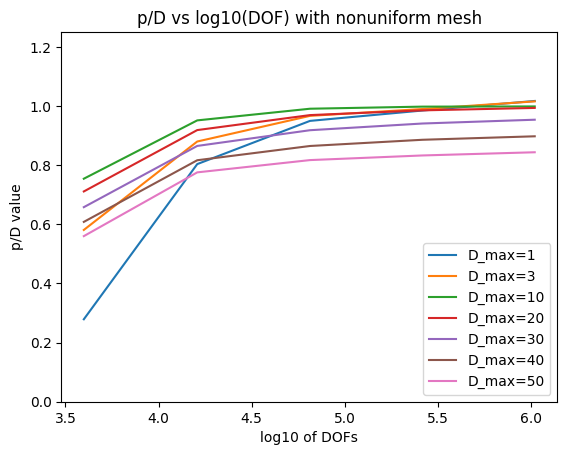

In [169]:
mat_r = 2
fit_size = 3
end_index = -1

# D_max = 1
N_2D_nonuniform_power_law_1 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_1 = np.array([21.773284010442467, 20.99416131249453, 20.97075937227958, 20.853958563955317, 20.774605386340035, 20.748560356649048, 20.74157969150418, 20.739797563083705, 20.739362530974876])
#lambda_inf_values_fit_1, C_values_fit_1, p_values_fit_1 = get_fit_parameters(N_2D_nonuniform_power_law_1, nonuniform_power_law_eigenvalues_1, mat_r, sz=fit_size)
p_values_fit_1 = get_p_vals(nonuniform_power_law_eigenvalues_1, 4)
start_index_1 = 2

# D_max = 3
N_2D_nonuniform_power_law_3 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_3 = np.array([42.01846569374839, 38.465686305068154, 38.15922022538205, 37.386566080514484, 37.04124657479253, 36.93929191554488, 36.91260312443812, 36.90583701647412, 36.90418206279903])
#lambda_inf_values_fit_3, C_values_fit_3, p_values_fit_3 = get_fit_parameters(N_2D_nonuniform_power_law_3, nonuniform_power_law_eigenvalues_3, mat_r, sz=fit_size)
p_values_fit_3 = get_p_vals(nonuniform_power_law_eigenvalues_3, 4)
start_index_3 = 2

# D_max = 10
N_2D_nonuniform_power_law_10 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_10 = np.array([111.2930724642858, 88.7236424042575, 83.0962729553513, 76.0980574630824, 73.63823274104865, 72.98049760099619, 72.81398337118185, 72.77223958382453, 72.76178456094868])
#lambda_inf_values_fit_10, C_values_fit_10, p_values_fit_10 = get_fit_parameters(N_2D_nonuniform_power_law_10, nonuniform_power_law_eigenvalues_10, mat_r, sz=fit_size)
p_values_fit_10 = get_p_vals(nonuniform_power_law_eigenvalues_10, 4)
start_index_10 = 2

# D_max = 20
N_2D_nonuniform_power_law_20 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_20 = np.array([209.81510323666168, 149.63905719881294, 131.51358272171294, 113.85934581375162, 107.27234415100703, 105.42911730708116, 104.94833315737554, 104.8256748043866, 104.79473878346846])
#lambda_inf_values_fit_20, C_values_fit_20, p_values_fit_20 = get_fit_parameters(N_2D_nonuniform_power_law_20, nonuniform_power_law_eigenvalues_20, mat_r, sz=fit_size)
p_values_fit_20 = get_p_vals(nonuniform_power_law_eigenvalues_20, 4)
start_index_20 = 2

# D_max = 30
N_2D_nonuniform_power_law_30 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_30 = np.array([308.2663995637128, 199.27802135923343, 170.20839651503525, 143.0193894804991, 132.09861464390463, 128.80698974826026, 127.88532885649538, 127.63524458192579, 127.56858551883091])
#lambda_inf_values_fit_30, C_values_fit_30, p_values_fit_30 = get_fit_parameters(N_2D_nonuniform_power_law_30, nonuniform_power_law_eigenvalues_30, mat_r, sz=fit_size)
p_values_fit_30 = get_p_vals(nonuniform_power_law_eigenvalues_30, 4)
start_index_30 = 2

#D_max = 40
N_2D_nonuniform_power_law_40 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_40 = np.array([406.698368702465, 237.7329533337307, 202.06502782795334, 167.18525451651084, 152.17486648519562, 147.33649945449386, 145.877762716656, 145.45059137014044, 145.32752265242652])
#lambda_inf_values_fit_40, C_values_fit_40, p_values_fit_40 = get_fit_parameters(N_2D_nonuniform_power_law_40, nonuniform_power_law_eigenvalues_40, mat_r, sz=fit_size)
p_values_fit_40 = get_p_vals(nonuniform_power_law_eigenvalues_40, 4)
start_index_40 = 2

#D_max = 50
N_2D_nonuniform_power_law_50 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529])
nonuniform_power_law_eigenvalues_50 = np.array([505.12231627976263, 266.41425218381045, 228.3178083501099, 187.753010097239, 169.0909507535099, 162.72361503817922, 160.67268782378457, 160.02627130758353, 159.82556661088873])
#lambda_inf_values_fit_50, C_values_fit_50, p_values_fit_50 = get_fit_parameters(N_2D_nonuniform_power_law_50, nonuniform_power_law_eigenvalues_50, mat_r, sz=fit_size)
p_values_fit_50 = get_p_vals(nonuniform_power_law_eigenvalues_50, 4)
start_index_50 = 2

# set a maximum value for the p_value_fit arrays
p_values_fit_1 = np.clip(p_values_fit_1, a_min=None, a_max=2)
p_values_fit_3 = np.clip(p_values_fit_3, a_min=None, a_max=2)
p_values_fit_10 = np.clip(p_values_fit_10, a_min=None, a_max=2)
p_values_fit_20 = np.clip(p_values_fit_20, a_min=None, a_max=2)
p_values_fit_30 = np.clip(p_values_fit_30, a_min=None, a_max=2)
p_values_fit_40 = np.clip(p_values_fit_40, a_min=None, a_max=2)
p_values_fit_50 = np.clip(p_values_fit_50, a_min=None, a_max=2)

'''plt.plot(np.log10(N_2D_nonuniform_power_law_3[start_index_1 + fit_size - 1:end_index]), p_values_fit_1[start_index_1:end_index], label="D_max=1")
plt.plot(np.log10(N_2D_nonuniform_power_law_3[start_index_3 + fit_size - 1:end_index]), p_values_fit_3[start_index_3:end_index], label="D_max=3")
plt.plot(np.log10(N_2D_nonuniform_power_law_10[start_index_10 + fit_size - 1:end_index]), p_values_fit_10[start_index_10:end_index], label="D_max=10")
plt.plot(np.log10(N_2D_nonuniform_power_law_20[start_index_20 + fit_size - 1:end_index]), p_values_fit_20[start_index_20:end_index], label="D_max=20")
plt.plot(np.log10(N_2D_nonuniform_power_law_30[start_index_30 + fit_size - 1:end_index]), p_values_fit_30[start_index_30:end_index], label="D_max=30")
plt.plot(np.log10(N_2D_nonuniform_power_law_40[start_index_40 + fit_size - 1:end_index]), p_values_fit_40[start_index_40:end_index], label="D_max=40")
plt.plot(np.log10(N_2D_nonuniform_power_law_50[start_index_50 + fit_size - 1:end_index]), p_values_fit_50[start_index_50:end_index], label="D_max=50")'''

plt.plot(np.log10(N_2D_nonuniform_power_law_3[start_index_1 + fit_size - 1:]), p_values_fit_1[start_index_1:], label="D_max=1")
plt.plot(np.log10(N_2D_nonuniform_power_law_3[start_index_3 + fit_size - 1:]), p_values_fit_3[start_index_3:], label="D_max=3")
plt.plot(np.log10(N_2D_nonuniform_power_law_10[start_index_10 + fit_size - 1:]), p_values_fit_10[start_index_10:], label="D_max=10")
plt.plot(np.log10(N_2D_nonuniform_power_law_20[start_index_20 + fit_size - 1:]), p_values_fit_20[start_index_20:], label="D_max=20")
plt.plot(np.log10(N_2D_nonuniform_power_law_30[start_index_30 + fit_size - 1:]), p_values_fit_30[start_index_30:], label="D_max=30")
plt.plot(np.log10(N_2D_nonuniform_power_law_40[start_index_40 + fit_size - 1:]), p_values_fit_40[start_index_40:], label="D_max=40")
plt.plot(np.log10(N_2D_nonuniform_power_law_50[start_index_50 + fit_size - 1:]), p_values_fit_50[start_index_50:], label="D_max=50")

plt.title("p/D vs log10(DOF) with nonuniform mesh")
plt.xlabel("log10 of DOFs")
plt.ylabel("p/D value")
plt.legend()
plt.ylim([0, 1.25])
plt.show()



# same plot but for the uniform results of the same simulations

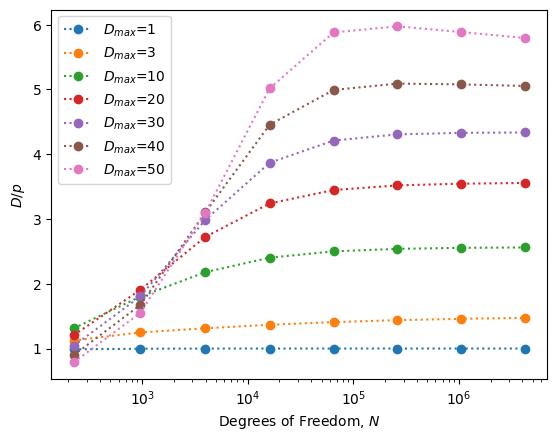

In [324]:
mat_r = 2
fit_size = 3

start_index = 0
level_list = [2,3,4,5,6,7,8,9]
N_2D_uniform = [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529,4190209]
D_max_values = [1,3,10,20,30,40,50]

uniform_eigenvalues_1 = np.array([21.77328401044247, 20.994161312494537, 20.802707356797878, 20.755068235068748, 20.743172706514034, 20.740199718588208, 20.739456527549464, 20.739270733319604, 20.739224284637718, 20.739212673877596])
#lambda_inf_values_fit_1, C_values_fit_1, p_values_fit_1 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_1, mat_r, sz=fit_size)
p_values_fit_1 = get_p_vals(uniform_eigenvalues_1, 4)

uniform_eigenvalues_3 = np.array([42.018465693748375, 38.46568630506815, 37.431694455922965, 37.091066849242935, 36.97261128693087, 36.929645581948854, 36.91359642681869, 36.90747789876388, 36.90511260452843, 36.90418969992967])
#lambda_inf_values_fit_3, C_values_fit_3, p_values_fit_3 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_3, mat_r, sz=fit_size)
p_values_fit_3 = get_p_vals(uniform_eigenvalues_3, 4)

uniform_eigenvalues_10 = np.array([111.29307246428579, 88.72364240425752, 80.87534653712603, 77.24110996032057, 75.31771940270083, 74.23761428240432, 73.61728908017766, 73.25799045612764, 73.0491971354478, 72.92770618619892])
#lambda_inf_values_fit_10, C_values_fit_10, p_values_fit_10 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_10, mat_r, sz=fit_size)
p_values_fit_10 = get_p_vals(uniform_eigenvalues_10, 4)

uniform_eigenvalues_20 = np.array([209.8151032366616, 149.63905719881294, 130.57947973589785, 121.37448945581022, 115.84145427267676, 112.23486917583263, 109.82280389756744, 108.19626222877258, 107.09622248298673, 106.35136022694223])
#lambda_inf_values_fit_20, C_values_fit_20, p_values_fit_20 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_20, mat_r, sz=fit_size)
p_values_fit_20 = get_p_vals(uniform_eigenvalues_20, 4)

uniform_eigenvalues_30 = np.array([308.2663995637128, 199.2780213592333, 170.51131336008223, 157.17062011330552, 148.78554182783793, 142.92636644185424, 138.71093767099845, 135.6559573837216, 133.4381359847393, 131.8273445714143])
#lambda_inf_values_fit_30, C_values_fit_30, p_values_fit_30 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_30, mat_r, sz=fit_size)
p_values_fit_30 = get_p_vals(uniform_eigenvalues_30, 4)

uniform_eigenvalues_40 = np.array([406.69836870246525, 237.73295333373096, 201.6855925469836, 185.96032704043412, 175.90220542061948, 168.53414222043497, 162.95291309794592, 158.70246889643624, 155.46759092811416, 153.00890909626864])
#lambda_inf_values_fit_40, C_values_fit_40, p_values_fit_40 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_40, mat_r, sz=fit_size)
p_values_fit_40 = get_p_vals(uniform_eigenvalues_40, 4)

uniform_eigenvalues_50 = np.array([505.12231627976263, 266.41425218381096, 225.41276660141602, 208.65561888500943, 197.9447643683776, 189.82035759063191, 183.40271706897948, 178.31425602446132, 174.29375281675246, 171.1288897305941])
#lambda_inf_values_fit_50, C_values_fit_50, p_values_fit_50 = get_fit_parameters(N_2D_uniform, uniform_eigenvalues_50, mat_r, sz=fit_size)
p_values_fit_50 = get_p_vals(uniform_eigenvalues_50, 4)

p_values_fit_combined = [p_values_fit_1, p_values_fit_3, p_values_fit_10, p_values_fit_20, p_values_fit_30, p_values_fit_40, p_values_fit_50]

# set a maximum value for the p_value_fit arrays
p_values_fit_combined = [np.clip(p_values_fit_combined[i], a_min=None, a_max=2) for i in range(len(p_values_fit_combined))]

# plot the p values
for i in range(len(p_values_fit_combined)):
    # DOF on x axis
    plt.semilogx(N_2D_uniform[start_index + fit_size - 1:], 1/p_values_fit_combined[i][start_index:], ':o', label=r'$D_{max}$='+str(D_max_values[i]))

    # level on x axis
    #plt.plot(level_list[start_index + fit_size - 1:], p_values_fit_combined[i][start_index:], label="D_max="+str(D_max_values[i]))

#plt.title("D/p vs DOF with uniform mesh")
plt.xlabel(r'Degrees of Freedom, $N$')
plt.ylabel(r"$D/p$")
plt.legend()
plt.show()




In [ ]:
D_max_list = [10]

# nonuniform with higher gamma values

In [290]:
#D_max_list = [1,3,10,20,30,40,50]
D_max_list = [50]
#gamma_list = [1, 2.1, 3.8, 5, 5.8, 6.2, 6.5]
gamma_list = [6.5]
refinement = 12
mat_refinement = 2
for D_i, D_max in enumerate(D_max_list):
    Data_dict = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for r in range(mat_refinement, refinement): # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, min_r=r, max_r=-1, D_max=D_max, D_min=1.0, gamma=gamma_list[D_i], do_plot=False, grid="nonuniform_power_law")
        Data_dict["levels"].append(r)
        Data_dict["lambda1"].append(float(lambda1))
        Data_dict["full_size"].append(full_size)
        Data_dict["free_size"].append(free_size)
        Data_dict["u_full"].append(u_full)
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict["free_size"])
    print("eigenvalues: ", Data_dict["lambda1"])

D_max: 50, level: 2, lambda1: 505.12231627976263, full_size: 25, free_size: 9
D_max: 50, level: 3, lambda1: 266.4142521838108, full_size: 81, free_size: 49
D_max: 50, level: 4, lambda1: 241.50367933113134, full_size: 289, free_size: 225
D_max: 50, level: 5, lambda1: 194.11803041654076, full_size: 1089, free_size: 961
D_max: 50, level: 6, lambda1: 170.20737765349983, full_size: 4225, free_size: 3969
D_max: 50, level: 7, lambda1: 162.64290367575202, full_size: 16641, free_size: 16129
D_max: 50, level: 8, lambda1: 160.5181832025879, full_size: 66049, free_size: 65025
D_max: 50, level: 9, lambda1: 159.98444319980507, full_size: 263169, free_size: 261121
D_max: 50, level: 10, lambda1: 160.4143116156581, full_size: 1050625, free_size: 1046529
D_max: 50, level: 11, lambda1: 163.5865698280449, full_size: 4198401, free_size: 4190209
DOFs:  [9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209]
eigenvalues:  [505.12231627976263, 266.4142521838108, 241.50367933113134, 194.11803041654076,

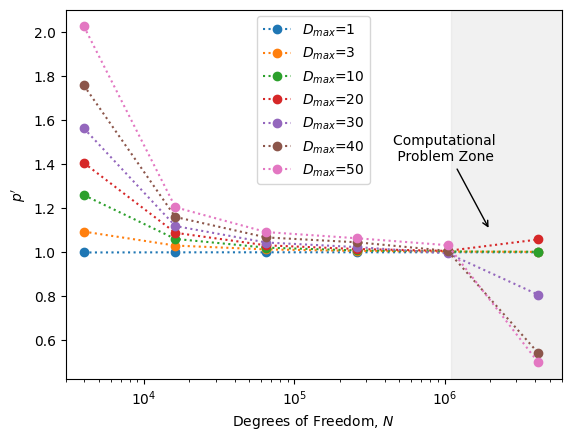

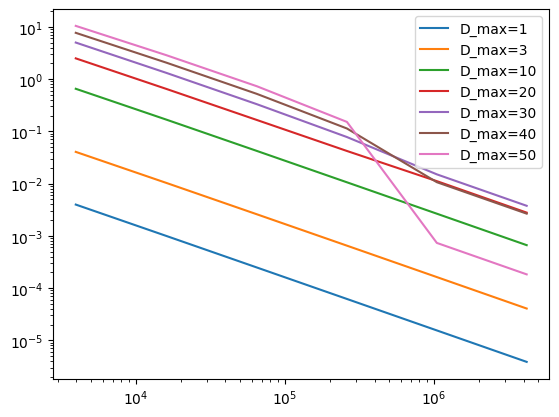

In [16]:
mat_r = 2
fit_size = 3
start_index = 2
end_index = -1

D_max_values = [1,3,10,20,30,40,50]

# D_max = 1, gamma = 1
N_2D_nonuniform_power_law_1 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_1 = np.array([21.77328401044247, 20.994161312494537, 20.80270735679787, 20.755068235068745, 20.743172706514034, 20.740199718588208, 20.739456527549443, 20.739270733319604, 20.739224284637732, 20.739212673877603])
#lambda_inf_values_fit_1, C_values_fit_1, p_values_fit_1 = get_fit_parameters(N_2D_nonuniform_power_law_1, nonuniform_power_law_eigenvalues_1, mat_r, sz=fit_size)
p_values_fit_1 = get_p_vals(nonuniform_power_law_eigenvalues_1, 4)
lambda_inf_1 = nonuniform_power_law_eigenvalues_1[-1] - (nonuniform_power_law_eigenvalues_1[-2] - nonuniform_power_law_eigenvalues_1[-1]) / 3 # find the eigenvalue being approached assuming p=1 at the last two points
start_index_1 = 2

# D_max = 3, gamma = 2.1
N_2D_nonuniform_power_law_3 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_3 = np.array([42.01846569374839, 38.46568630506813, 37.470951058242036, 37.059790589474396, 36.944007144719684, 36.91384887193295, 36.90617501355388, 36.90423977116473, 36.9037537087073, 36.9036318833449])
#lambda_inf_values_fit_3, C_values_fit_3, p_values_fit_3 = get_fit_parameters(N_2D_nonuniform_power_law_3, nonuniform_power_law_eigenvalues_3, mat_r, sz=fit_size)
p_values_fit_3 = get_p_vals(nonuniform_power_law_eigenvalues_3, 4)
lambda_inf_3 = nonuniform_power_law_eigenvalues_3[-1] - (nonuniform_power_law_eigenvalues_3[-2] - nonuniform_power_law_eigenvalues_3[-1]) / 3
start_index_3 = 2

# D_max = 10, gamma = 3.8
N_2D_nonuniform_power_law_10 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_10 = np.array([111.29307246428583, 88.72364240425752, 80.58478389157247, 75.20120839593912, 73.40998961054258, 72.92519036743374, 72.80048415743883, 72.76893656217554, 72.7610080947321, 72.75901898238963])
#lambda_inf_values_fit_10, C_values_fit_10, p_values_fit_10 = get_fit_parameters(N_2D_nonuniform_power_law_10, nonuniform_power_law_eigenvalues_10, mat_r, sz=fit_size)
p_values_fit_10 = get_p_vals(nonuniform_power_law_eigenvalues_10, 4)
lambda_inf_10 = nonuniform_power_law_eigenvalues_10[-1] - (nonuniform_power_law_eigenvalues_10[-2] - nonuniform_power_law_eigenvalues_10[-1]) / 3
start_index_10 = 2

# D_max = 20, gamma=5
N_2D_nonuniform_power_law_20 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_20 = np.array([209.81510323666166, 149.63905719881282, 131.5135827217129, 113.85934581375142, 107.27234415100779, 105.42911730710725, 104.94833315736311, 104.82567480496948, 104.79473872940899, 104.78639267072943])
#lambda_inf_values_fit_20, C_values_fit_20, p_values_fit_20 = get_fit_parameters(N_2D_nonuniform_power_law_20, nonuniform_power_law_eigenvalues_20, mat_r, sz=fit_size)
p_values_fit_20 = get_p_vals(nonuniform_power_law_eigenvalues_20, 4)
lambda_inf_20 = nonuniform_power_law_eigenvalues_20[-1] - (nonuniform_power_law_eigenvalues_20[-2] - nonuniform_power_law_eigenvalues_20[-1]) / 3
start_index_20 = 2

# D_max = 30, gamma=5.8
N_2D_nonuniform_power_law_30 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_30 = np.array([308.26639956371287, 199.27802135923338, 176.18145610238915, 145.28075384267584, 132.55048941526368, 128.86156021024712, 127.88334170947432, 127.63083211384387, 127.56811284221033, 127.55684996653007])
#lambda_inf_values_fit_30, C_values_fit_30, p_values_fit_30 = get_fit_parameters(N_2D_nonuniform_power_law_30, nonuniform_power_law_eigenvalues_30, mat_r, sz=fit_size)
p_values_fit_30 = get_p_vals(nonuniform_power_law_eigenvalues_30, 4)
lambda_inf_30 = nonuniform_power_law_eigenvalues_30[-1] - (nonuniform_power_law_eigenvalues_30[-2] - nonuniform_power_law_eigenvalues_30[-1]) / 3
start_index_30 = 2

#D_max = 40, gamma = 6.2
N_2D_nonuniform_power_law_40 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_40 = np.array([406.69836870246525, 237.73295333373105, 212.34487559312922, 171.52900936989258, 152.9764434524756, 147.3587117805132, 145.82565662703468, 145.41863273504416, 145.31597354257195, 145.30800218108368])
#lambda_inf_values_fit_40, C_values_fit_40, p_values_fit_40 = get_fit_parameters(N_2D_nonuniform_power_law_40, nonuniform_power_law_eigenvalues_40, mat_r, sz=fit_size)
p_values_fit_40 = get_p_vals(nonuniform_power_law_eigenvalues_40, 4)
lambda_inf_40 = nonuniform_power_law_eigenvalues_40[-1] - (nonuniform_power_law_eigenvalues_40[-2] - nonuniform_power_law_eigenvalues_40[-1]) / 3
start_index_40 = 2

#D_max = 50, gamma = 6.5
N_2D_nonuniform_power_law_50 = np.array([9, 49, 225, 961, 3969, 16129, 65025, 261121, 1046529, 4190209])
nonuniform_power_law_eigenvalues_50 = np.array([505.12231627976263, 266.41425218381073, 241.50367933113128, 194.11803041654125, 170.20737765355128, 162.6429036697923, 160.51818317435837, 159.94100044506527, 159.790335519135, 159.78978665747704])
#lambda_inf_values_fit_50, C_values_fit_50, p_values_fit_50 = get_fit_parameters(N_2D_nonuniform_power_law_50, nonuniform_power_law_eigenvalues_50, mat_r, sz=fit_size)
p_values_fit_50 = get_p_vals(nonuniform_power_law_eigenvalues_50, 4)
lambda_inf_50 = nonuniform_power_law_eigenvalues_50[-1] - (nonuniform_power_law_eigenvalues_50[-2] - nonuniform_power_law_eigenvalues_50[-1]) / 3
start_index_50 = 2

N_values_combined = [N_2D_nonuniform_power_law_1, N_2D_nonuniform_power_law_3, N_2D_nonuniform_power_law_10, N_2D_nonuniform_power_law_20, N_2D_nonuniform_power_law_30, N_2D_nonuniform_power_law_40, N_2D_nonuniform_power_law_50]
eigenvalues_combined = [nonuniform_power_law_eigenvalues_1, nonuniform_power_law_eigenvalues_3, nonuniform_power_law_eigenvalues_10, nonuniform_power_law_eigenvalues_20, nonuniform_power_law_eigenvalues_30, nonuniform_power_law_eigenvalues_40, nonuniform_power_law_eigenvalues_50]
p_values_fit_combined = [p_values_fit_1, p_values_fit_3, p_values_fit_10, p_values_fit_20, p_values_fit_30, p_values_fit_40, p_values_fit_50]
lambda_inf_combined = [lambda_inf_1, lambda_inf_3, lambda_inf_10, lambda_inf_20, lambda_inf_30, lambda_inf_40, lambda_inf_50]

# set a maximum value for the p_value_fit arrays
p_values_fit_combined = [np.clip(p_values_fit_combined[i], a_min=None, a_max=2) for i in range(len(p_values_fit_combined))]

# plot the p values
for i in range(len(p_values_fit_combined)):
    # DOF on x axis
    plt.semilogx(N_values_combined[i][start_index + fit_size - 1:], 1/p_values_fit_combined[i][start_index:], ':o', label=r'$D_{max}$='+str(D_max_values[i]))

    # DOF on x axis, remove last point
    #plt.semilogx(N_values_combined[i][start_index + fit_size - 1:-1], 1/p_values_fit_combined[i][start_index:-1], ':o', label=r'$D_{max}$='+str(D_max_values[i]))

    
    # level on x axis
    #plt.plot(level_list[start_index + fit_size - 1:], p_values_fit_combined[i][start_index:], label="D_max="+str(D_max_values[i]))

# show the computational problem region
plt.annotate(
    "Computational \n Problem Zone",
    xy=(2000000, 1.1),
    xytext=(-70, 50),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

#plt.title("D/p vs DOF with nonuniform mesh")
plt.xlabel(r'Degrees of Freedom, $N$')
plt.ylabel(r"$p'$")
plt.legend()
plt.xlim(3000,6000000) # with the last point/shaded region
#plt.xlim(3000,2000000) # without the last point/shaded region
#plt.ylim([0.75,1.25])

ax = plt.gca()

# Shade the region containing the final data point
x_start = 1100000
x_end   = 6000000

ax.axvspan(
    x_start,
    x_end,
    color='lightgray',
    alpha=0.3,
    zorder=0
)

plt.show()



# plot the eigenvalue
for i in range(len(p_values_fit_combined)):
    # DOF on x axis
    plt.loglog(N_values_combined[i][start_index + fit_size - 1:], eigenvalues_combined[i][start_index + fit_size - 1:] - lambda_inf_combined[i], label="D_max="+str(D_max_values[i]))

plt.legend()
plt.show()

